In [1]:
from pathlib import Path
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from dotenv import load_dotenv
from pyspark.ml.linalg import SparseVector, VectorUDT
from pyspark.ml.regression import LinearRegression
from pyspark import StorageLevel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()

True

In [2]:
spark = (
    SparkSession.builder
    .appName("uk-property-flip-detector")
    .config("spark.jars", "jars/postgresql-jdbc.jar")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)

26/10/02 02:41:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/02 02:41:20 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
BASE_YEAR = 1995

df = (
    spark.read
    .format("jdbc")
    .option("url", f"jdbc:postgresql://{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}")
    .option("dbtable", "repeat_sale_pairs_regression")
    .option("user", os.environ["PGUSER"])
    .option("password", os.environ["PGPASSWORD"])
    .option("driver", "org.postgresql.Driver")
    .option("partitionColumn", "property_id")
    .option("lowerBound", "1")
    .option("upperBound", "15184630")
    .option("numPartitions", "8")
    .load()
    # new-build test: keep only pairs where neither sale was a new build
    .filter((F.col("prev_old_new") == "N") & (F.col("curr_old_new") == "N"))
)

pairs = (
    df
    .withColumn(
        "prev_period",
        (F.year("prev_date_of_transfer") - BASE_YEAR) * 12
        + (F.month("prev_date_of_transfer") - 1),
    )
    .withColumn(
        "curr_period",
        (F.year("curr_date_of_transfer") - BASE_YEAR) * 12
        + (F.month("curr_date_of_transfer") - 1),
    )
    .withColumn("log_price_ratio", F.col("log_price_ratio").cast("double"))
)

MAX_PERIOD = 377

pairs_nn = (
    pairs
    .filter(F.col("curr_period") <= MAX_PERIOD)
    .filter(F.col("curr_period") != F.col("prev_period"))
    .select("property_id", "prev_period", "curr_period", "log_price_ratio")
    .cache()
)

print("N/N pairs after filtering:", pairs_nn.count())

N/N pairs after filtering: 11039495


In [4]:
N_PARAMS = MAX_PERIOD
MIN_INTERVAL = 24  # months
dates = pd.date_range("1995-01-01", periods=MAX_PERIOD + 1, freq="MS")

# Arrow off: incompatible with VectorUDT
@F.udf(returnType=VectorUDT(), useArrow=False)
def bmn_vector(prev_p, curr_p):
    entries = {}
    if prev_p > 0:
        entries[prev_p - 1] = -1.0
    if curr_p > 0:
        entries[curr_p - 1] = 1.0
    return SparseVector(N_PARAMS, entries)

def fit_bmn(df, weight_col=None):
    params = dict(featuresCol="features", labelCol="y", fitIntercept=False,
                  solver="normal", regParam=0.0, standardization=False)
    if weight_col:
        params["weightCol"] = weight_col
    return LinearRegression(**params).fit(df)

def to_index(model, name):
    beta = np.concatenate([[0.0], model.coefficients.toArray()])
    return pd.Series(100 * np.exp(beta), index=dates, name=name)

def save_index(series, out_dir, filename):
    series.rename_axis("month").to_frame().to_csv(out_dir / filename)

out = Path("data/processed")

In [5]:
reg_long = (
    pairs_nn
    .withColumn("interval", (F.col("curr_period") - F.col("prev_period")).cast("double"))
    .filter(F.col("interval") >= MIN_INTERVAL)
    .withColumn("features", bmn_vector("prev_period", "curr_period"))
    .select("features", F.col("log_price_ratio").alias("y"), "interval")
    .persist(StorageLevel.MEMORY_AND_DISK)
)
reg_long.count()  # roughly 9.5M

9528550

In [6]:
m1 = fit_bmn(reg_long)

26/10/02 02:43:18 WARN Instrumentation: [cb16a144] regParam is zero, which might cause numerical instability and overfitting.
netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory
netlib-lapack: JNI_OnLoad: dlopen(liblapack.so.3) failed: liblapack.so.3: cannot open shared object file: No such file or directory


In [7]:
r = m1.transform(reg_long).withColumn("e2", (F.col("y") - F.col("prediction")) ** 2)
s = r.agg(
    F.covar_samp("interval", "e2").alias("cov"),
    F.var_samp("interval").alias("var"),
    F.avg("interval").alias("mx"),
    F.avg("e2").alias("mz"),
).first()

b2 = s["cov"] / s["var"]
a2 = s["mz"] - b2 * s["mx"]
print(f"a = {a2:.5f}, b = {b2:.6f}")

a = 0.05198, b = 0.000193


In [8]:
m3 = fit_bmn(
    reg_long.withColumn("w", 1.0 / (F.lit(a2) + F.lit(b2) * F.col("interval"))),
    "w",
)
bmn_cs_nn = to_index(m3, "case_shiller_min24m_nn")
print(bmn_cs_nn.iloc[-1])

save_index(bmn_cs_nn, out, f"bmn_index_case_shiller_min{MIN_INTERVAL}m_nn.csv")

26/10/02 02:43:27 WARN Instrumentation: [15e659ab] regParam is zero, which might cause numerical instability and overfitting.


576.027213204589


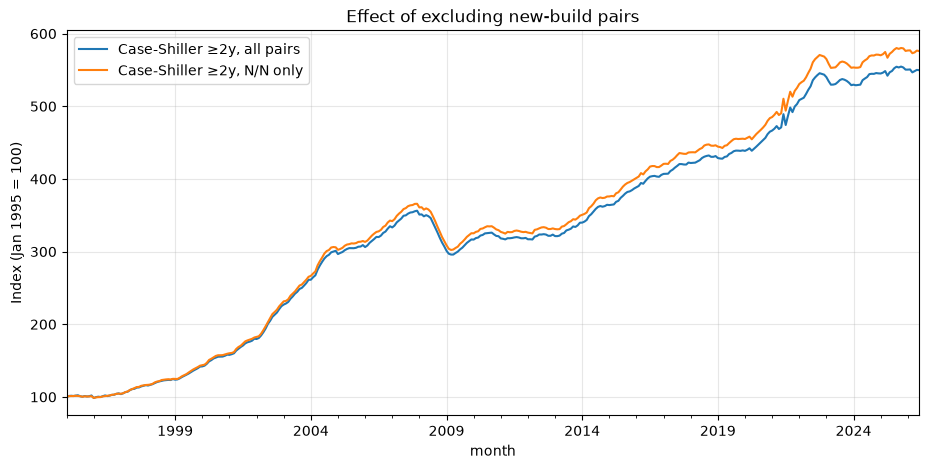

Final level difference: +4.8%


In [9]:
cs_all = pd.read_csv(out / f"bmn_index_case_shiller_min{MIN_INTERVAL}m.csv",
                     index_col="month", parse_dates=True).squeeze()

fig, ax = plt.subplots(figsize=(11, 5))
cs_all.plot(ax=ax, label="Case-Shiller ≥2y, all pairs")
bmn_cs_nn.plot(ax=ax, label="Case-Shiller ≥2y, N/N only")
ax.set_title("Effect of excluding new-build pairs")
ax.set_ylabel("Index (Jan 1995 = 100)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Final level difference: {bmn_cs_nn.iloc[-1] / cs_all.iloc[-1] - 1:+.1%}")

In [10]:
reg_long.unpersist()
pairs_nn.unpersist()

DataFrame[property_id: bigint, prev_period: int, curr_period: int, log_price_ratio: double]